# Training Notebook

## Install Dependicies on HiPerGator

In [1]:
%pip install datasets transformers accelerate seqeval --quiet

Note: you may need to restart the kernel to use updated packages.


## Imports

In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import Counter
from datasets import load_dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.utils.class_weight import compute_class_weight
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## Config

In [5]:
# All hyperparameters in one place -  makes it easy for us to tune
CONFIG = {
    # General
    'seed'        : 42,
    'max_len'     : 128,
    'batch_size'  : 64,
    'num_classes' : 5,

    # LSTM
    'vocab_size'  : 30000,
    'embed_dim'   : 128,
    'hidden_dim'  : 256,
    'num_layers'  : 2,
    'dropout'     : 0.3,
    'lstm_lr'     : 1e-3,
    'lstm_epochs' : 10,

    # DistilBERT
    'bert_lr'     : 2e-5,
    'bert_epochs' : 4,
}

LABEL_NAMES = ['background', 'objective', 'methods', 'results', 'conclusions']
LABEL2IDX   = {l: i for i, l in enumerate(LABEL_NAMES)}
IDX2LABEL   = {i: l for l, i in LABEL2IDX.items()}

# Reproducibility
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Load Data

In [6]:
ds = load_dataset('armanc/pubmed-rct20k')

train_df = ds['train'].to_pandas()
val_df   = ds['validation'].to_pandas()
test_df  = ds['test'].to_pandas()

# Encode labels
train_df['label_idx'] = train_df['label'].map(LABEL2IDX)
val_df['label_idx']   = val_df['label'].map(LABEL2IDX)
test_df['label_idx']  = test_df['label'].map(LABEL2IDX)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print('Label encoding:', LABEL2IDX)

Repo card metadata block was not found. Setting CardData to empty.


Train: 176,642 | Val: 29,672 | Test: 29,578
Label encoding: {'background': 0, 'objective': 1, 'methods': 2, 'results': 3, 'conclusions': 4}


## Class Weights (for imbalance)

In [8]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(CONFIG['num_classes']),
    y=train_df['label_idx'].values
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print('Class weights:')
for i, w in enumerate(class_weights):
    print(f'  {IDX2LABEL[i]:<15} {w:.4f}')

Class weights:
  background      1.9198
  objective       2.5530
  methods         0.5959
  results         0.6096
  conclusions     1.3004


## Build Vocab

In [9]:
def build_vocab(texts, max_vocab_size):
    counter = Counter()
    for text in texts:
        counter.update(text.lower().split())
    
    # Reserve 0 for padding, 1 for unknown
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab_size - 2):
        vocab[word] = len(vocab)
    
    return vocab

vocab = build_vocab(train_df['text'].tolist(), CONFIG['vocab_size'])
print(f'Vocab size: {len(vocab):,}')
print(f'Sample entries: { {k: vocab[k] for k in list(vocab)[:5]} }')

Vocab size: 30,000
Sample entries: {'<PAD>': 0, '<UNK>': 1, '@': 2, ',': 3, '.': 4}


## LSTM Dataset Class

In [10]:
class LSTMDataset(Dataset):
    def __init__(self, df, vocab, max_len):
        self.texts  = df['text'].tolist()
        self.labels = df['label_idx'].tolist()
        self.vocab  = vocab
        self.max_len = max_len

    def encode(self, text):
        tokens = text.lower().split()[:self.max_len]
        ids = [self.vocab.get(t, self.vocab['<UNK>']) for t in tokens]
        # Pad or truncate to max_len
        ids += [self.vocab['<PAD>']] * (self.max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.encode(self.texts[idx]), torch.tensor(self.labels[idx], dtype=torch.long)

train_lstm = LSTMDataset(train_df, vocab, CONFIG['max_len'])
val_lstm   = LSTMDataset(val_df,   vocab, CONFIG['max_len'])
test_lstm  = LSTMDataset(test_df,  vocab, CONFIG['max_len'])

train_loader_lstm = DataLoader(train_lstm, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader_lstm   = DataLoader(val_lstm,   batch_size=CONFIG['batch_size'])
test_loader_lstm  = DataLoader(test_lstm,  batch_size=CONFIG['batch_size'])

print(f'Batches — Train: {len(train_loader_lstm)} | Val: {len(val_loader_lstm)} | Test: {len(test_loader_lstm)}')

Batches — Train: 2761 | Val: 464 | Test: 463


## LSTM Model

In [11]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, _) = self.lstm(embedded)
        # Concatenate final forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))

lstm_model = LSTMClassifier(
    vocab_size  = len(vocab),
    embed_dim   = CONFIG['embed_dim'],
    hidden_dim  = CONFIG['hidden_dim'],
    num_layers  = CONFIG['num_layers'],
    num_classes = CONFIG['num_classes'],
    dropout     = CONFIG['dropout']
).to(device)

total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f'LSTM model ready. Trainable params: {total_params:,}')

LSTM model ready. Trainable params: 6,210,053


## LSTM Training Loop

In [13]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

criterion_lstm = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_lstm = Adam(lstm_model.parameters(), lr=CONFIG['lstm_lr'])
scheduler_lstm = ReduceLROnPlateau(optimizer_lstm, patience=2, factor=0.5)

print('Training setup ready.')

Training setup ready.


## Run LSTM Training

In [14]:
lstm_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')

for epoch in range(CONFIG['lstm_epochs']):
    train_loss, train_acc = train_epoch(lstm_model, train_loader_lstm, optimizer_lstm, criterion_lstm)
    val_loss, val_acc     = eval_epoch(lstm_model, val_loader_lstm, criterion_lstm)
    scheduler_lstm.step(val_loss)

    lstm_history['train_loss'].append(train_loss)
    lstm_history['val_loss'].append(val_loss)
    lstm_history['train_acc'].append(train_acc)
    lstm_history['val_acc'].append(val_acc)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(lstm_model.state_dict(), 'models/lstm_best.pt')
        tag = '  ← best'
    else:
        tag = ''

    print(f'Epoch {epoch+1:02d}/{CONFIG["lstm_epochs"]} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{tag}')

print('\nLSTM training complete.')

Epoch 01/10 | Train Loss: 0.7501 Acc: 0.7510 | Val Loss: 0.5932 Acc: 0.8201  ← best
Epoch 02/10 | Train Loss: 0.5881 Acc: 0.8192 | Val Loss: 0.5669 Acc: 0.8402  ← best
Epoch 03/10 | Train Loss: 0.5360 Acc: 0.8381 | Val Loss: 0.5339 Acc: 0.8425  ← best
Epoch 04/10 | Train Loss: 0.5002 Acc: 0.8491 | Val Loss: 0.5579 Acc: 0.8489
Epoch 05/10 | Train Loss: 0.4691 Acc: 0.8591 | Val Loss: 0.5576 Acc: 0.8502
Epoch 06/10 | Train Loss: 0.4425 Acc: 0.8665 | Val Loss: 0.5489 Acc: 0.8457
Epoch 07/10 | Train Loss: 0.3959 Acc: 0.8804 | Val Loss: 0.5759 Acc: 0.8474
Epoch 08/10 | Train Loss: 0.3739 Acc: 0.8866 | Val Loss: 0.5955 Acc: 0.8465
Epoch 09/10 | Train Loss: 0.3559 Acc: 0.8921 | Val Loss: 0.6148 Acc: 0.8448
Epoch 10/10 | Train Loss: 0.3271 Acc: 0.8997 | Val Loss: 0.6502 Acc: 0.8479

LSTM training complete.


## Plot LSTM Training Curves

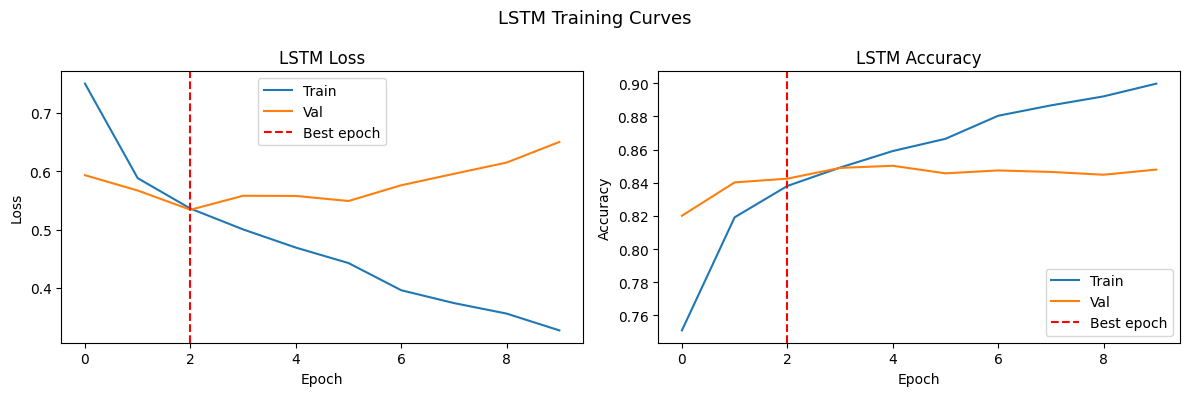

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lstm_history['train_loss'], label='Train')
axes[0].plot(lstm_history['val_loss'],   label='Val')
axes[0].axvline(x=2, color='red', linestyle='--', label='Best epoch')
axes[0].set_title('LSTM Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(lstm_history['train_acc'], label='Train')
axes[1].plot(lstm_history['val_acc'],   label='Val')
axes[1].axvline(x=2, color='red', linestyle='--', label='Best epoch')
axes[1].set_title('LSTM Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('LSTM Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('figures/lstm_curves.png', bbox_inches='tight')
plt.show()

## LSTM Test Evaluation

=== LSTM Test Set Results ===

              precision    recall  f1-score   support

  background       0.60      0.66      0.63      3077
   objective       0.64      0.64      0.64      2333
     methods       0.91      0.92      0.91      9884
     results       0.91      0.88      0.89      9713
 conclusions       0.78      0.77      0.78      4571

    accuracy                           0.83     29578
   macro avg       0.77      0.77      0.77     29578
weighted avg       0.84      0.83      0.83     29578



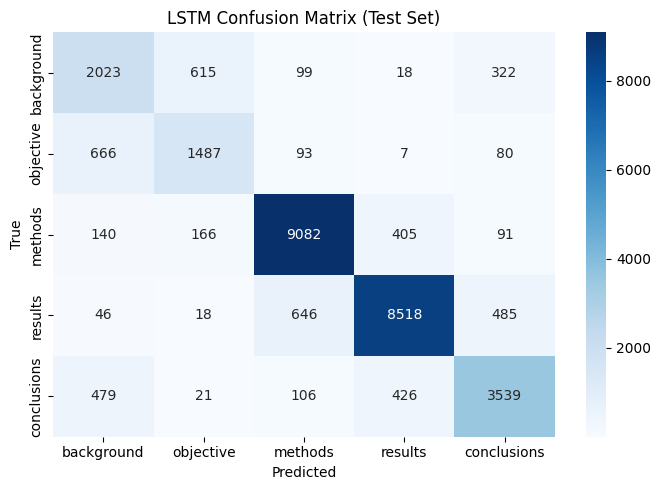

In [17]:
# Load best checkpoint
lstm_model.load_state_dict(torch.load('models/lstm_best.pt'))
lstm_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader_lstm:
        inputs = inputs.to(device)
        outputs = lstm_model(inputs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print('=== LSTM Test Set Results ===\n')
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title('LSTM Confusion Matrix (Test Set)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('figures/lstm_confusion.png', bbox_inches='tight')
plt.show()

## DistilBERT Dataset

In [18]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class BertDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts   = df['text'].tolist()
        self.labels  = df['label_idx'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_bert = BertDataset(train_df, tokenizer, CONFIG['max_len'])
val_bert   = BertDataset(val_df,   tokenizer, CONFIG['max_len'])
test_bert  = BertDataset(test_df,  tokenizer, CONFIG['max_len'])

train_loader_bert = DataLoader(train_bert, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader_bert   = DataLoader(val_bert,   batch_size=CONFIG['batch_size'])
test_loader_bert  = DataLoader(test_bert,  batch_size=CONFIG['batch_size'])

print(f'Batches — Train: {len(train_loader_bert)} | Val: {len(val_loader_bert)} | Test: {len(test_loader_bert)}')

Batches — Train: 2761 | Val: 464 | Test: 463


## Load DistilBERT model:

In [19]:
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=CONFIG['num_classes']
).to(device)

total_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f'DistilBERT ready. Trainable params: {total_params:,}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5290.09it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT ready. Trainable params: 66,957,317


## DistilBERT Training Loop

In [21]:
criterion_bert = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_bert = Adam(bert_model.parameters(), lr=CONFIG['bert_lr'])
scheduler_bert = ReduceLROnPlateau(optimizer_bert, patience=1, factor=0.5)

def train_epoch_bert(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch_bert(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)

            total_loss += loss.item()
            correct += (outputs.logits.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

print('DistilBERT training setup ready.')

DistilBERT training setup ready.


## Run DistilBERT Training

In [22]:
bert_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss_bert = float('inf')

for epoch in range(CONFIG['bert_epochs']):
    train_loss, train_acc = train_epoch_bert(bert_model, train_loader_bert, optimizer_bert, criterion_bert)
    val_loss, val_acc     = eval_epoch_bert(bert_model, val_loader_bert, criterion_bert)
    scheduler_bert.step(val_loss)

    bert_history['train_loss'].append(train_loss)
    bert_history['val_loss'].append(val_loss)
    bert_history['train_acc'].append(train_acc)
    bert_history['val_acc'].append(val_acc)

    if val_loss < best_val_loss_bert:
        best_val_loss_bert = val_loss
        torch.save(bert_model.state_dict(), 'models/bert_best.pt')
        tag = '  ← best'
    else:
        tag = ''

    print(f'Epoch {epoch+1:02d}/{CONFIG["bert_epochs"]} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{tag}')

print('\nDistilBERT training complete.')

Epoch 01/4 | Train Loss: 0.5513 Acc: 0.8382 | Val Loss: 0.4729 Acc: 0.8592  ← best
Epoch 02/4 | Train Loss: 0.4500 Acc: 0.8710 | Val Loss: 0.4644 Acc: 0.8636  ← best
Epoch 03/4 | Train Loss: 0.3869 Acc: 0.8903 | Val Loss: 0.4816 Acc: 0.8570
Epoch 04/4 | Train Loss: 0.3204 Acc: 0.9100 | Val Loss: 0.5224 Acc: 0.8604

DistilBERT training complete.
